### Problem Data

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

# Set random seed for reproducibility
np.random.seed(42)


# Depot
depot = "Masjid India, Kuala Lumpur"

# Van capacity (kg)
VAN_CAPACITY = 75

# Delivery locations data
# Format: [Name, Distance(km), Weight(kg), Priority(1-5)]
locations_data = [
    ["KLCC", 3.2, 12, 5],
    ["Chow Kit", 2.1, 8, 3],
    ["Titiwangsa", 4.5, 15, 4],
    ["Ampang", 7.8, 10, 5],
    ["Wangsa Maju", 9.2, 20, 2],
    ["Setapak", 8.5, 9, 3],
    ["Kampung Baru", 1.8, 14, 5],
    ["Brickfields", 5.3, 11, 4],
]

# Extract arrays for easier computation
location_names = [loc[0] for loc in locations_data]
distances = np.array([loc[1] for loc in locations_data])
weights = np.array([loc[2] for loc in locations_data])
priorities = np.array([loc[3] for loc in locations_data])

n_locations = len(locations_data)
print(f"Number of locations: {n_locations}")
print(f"Van capacity: {VAN_CAPACITY} kg")
print(f"Total weight of all locations: {np.sum(weights)} kg")
print(f"Total weight exceeds capacity by: {np.sum(weights) - VAN_CAPACITY} kg")

Number of locations: 8
Van capacity: 75 kg
Total weight of all locations: 99 kg
Total weight exceeds capacity by: 24 kg


### Set Fitness Function

In [17]:
# FITNESS FUNCTION (same for both algorithms)
def calculate_fitness(binary_solution):
    """
    Calculate fitness of a binary solution

    Fitness = Total Priority Score - Total Distance - Penalty

    Where:
    - Total Priority Score = Σ(Parcel Weight × Priority Level) for selected locations
    - Penalty = 100 × max(0, Total Weight - Van Capacity)
    """
    selected = binary_solution.astype(bool)

    total_weight = np.sum(weights[selected])
    total_priority_score = np.sum(weights[selected] * priorities[selected])
    total_distance = np.sum(distances[selected])

    # Penalty for exceeding capacity
    if total_weight > VAN_CAPACITY:
        penalty = 100 * (total_weight - VAN_CAPACITY)
    else:
        penalty = 0

    fitness = total_priority_score - total_distance - penalty

    return fitness, total_weight, total_priority_score, total_distance

def evaluate_population(population):
    """Evaluate all solutions in a population"""
    fitness_values = []
    weights_list = []
    priority_scores = []
    distances_list = []

    for solution in population:
        fit, w, ps, d = calculate_fitness(solution)
        fitness_values.append(fit)
        weights_list.append(w)
        priority_scores.append(ps)
        distances_list.append(d)

    return np.array(fitness_values), weights_list, priority_scores, distances_list

def get_solution_details(binary_solution):
    """Get detailed information about a solution"""
    selected = binary_solution.astype(bool)
    selected_names = [location_names[i] for i in range(n_locations) if selected[i]]
    fitness, total_weight, total_priority, total_distance = calculate_fitness(binary_solution)

    return {
        'binary': binary_solution.tolist(),
        'selected_locations': selected_names,
        'n_selected': len(selected_names),
        'total_weight': total_weight,
        'total_priority': total_priority,
        'total_distance': total_distance,
        'fitness': fitness
    }



### Apply GA & PSO

In [18]:


# GENETIC ALGORITHM
class GeneticAlgorithm:
    def __init__(self, n_locations, population_size=20, generations=40,
                 crossover_rate=0.85, mutation_rate=0.05):
        self.n_locations = n_locations
        self.population_size = population_size
        self.generations = generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate

        self.best_fitness_history = []
        self.avg_fitness_history = []
        self.best_solution = None

    def initialize_population(self):
        """Create random binary population"""
        population = np.random.randint(2, size=(self.population_size, self.n_locations))
        return population

    def roulette_wheel_selection(self, population, fitness_values):
        """Select parents using fitness-proportionate selection"""
        # Avoid negative fitness by shifting
        min_fitness = np.min(fitness_values)
        if min_fitness < 0:
            shifted_fitness = fitness_values - min_fitness + 1e-10
        else:
            shifted_fitness = fitness_values + 1e-10

        probabilities = shifted_fitness / np.sum(shifted_fitness)

        selected_indices = np.random.choice(
            self.population_size,
            size=self.population_size,
            p=probabilities,
            replace=True
        )
        return population[selected_indices]

    def single_point_crossover(self, parent1, parent2):
        """Perform single-point crossover"""
        if np.random.random() < self.crossover_rate:
            crossover_point = np.random.randint(1, self.n_locations)
            offspring1 = np.concatenate([parent1[:crossover_point], parent2[crossover_point:]])
            offspring2 = np.concatenate([parent2[:crossover_point], parent1[crossover_point:]])
            return offspring1, offspring2
        else:
            return parent1.copy(), parent2.copy()

    def mutate(self, offspring):
        """Apply bit-flip mutation"""
        mutation_mask = np.random.random(self.n_locations) < self.mutation_rate
        offspring[mutation_mask] = 1 - offspring[mutation_mask]
        return offspring

    def run(self, verbose=True):
        """Run the Genetic Algorithm"""
        # Initialize
        population = self.initialize_population()

        for generation in range(self.generations):
            # Evaluate
            fitness_values, weights_list, _, _ = evaluate_population(population)

            # Track best
            best_idx = np.argmax(fitness_values)
            best_fitness = fitness_values[best_idx]
            self.best_fitness_history.append(best_fitness)
            self.avg_fitness_history.append(np.mean(fitness_values))

            if best_fitness == self.best_fitness_history[-1] or generation == 0:
                self.best_solution = population[best_idx].copy()

            # Selection
            selected_pop = self.roulette_wheel_selection(population, fitness_values)

            # Create next generation
            next_population = []
            for i in range(0, self.population_size, 2):
                parent1 = selected_pop[i]
                parent2 = selected_pop[i + 1] if i + 1 < self.population_size else selected_pop[0]

                offspring1, offspring2 = self.single_point_crossover(parent1, parent2)
                offspring1 = self.mutate(offspring1)
                offspring2 = self.mutate(offspring2)

                next_population.append(offspring1)
                next_population.append(offspring2)

            population = np.array(next_population[:self.population_size])

            if verbose and (generation + 1) % 10 == 0:
                print(f"GA Generation {generation + 1}: Best Fitness = {best_fitness:.2f}, Avg = {np.mean(fitness_values):.2f}")

        return self.best_solution, self.best_fitness_history, self.avg_fitness_history




# BINARY PARTICLE SWARM OPTIMIZATION
class BinaryPSO:
    def __init__(self, n_locations, n_particles=20, iterations=40,
                 w=0.70, c1=1.50, c2=1.50):
        self.n_locations = n_locations
        self.n_particles = n_particles
        self.iterations = iterations
        self.w = w  # Inertia weight
        self.c1 = c1  # Cognitive coefficient
        self.c2 = c2  # Social coefficient

        self.best_fitness_history = []
        self.best_solution = None

    def sigmoid(self, v):
        """Sigmoid function for binary PSO"""
        return 1 / (1 + np.exp(-v))

    def initialize_swarm(self):
        """Initialize particles with random positions and velocities"""
        # Random binary positions
        positions = np.random.randint(2, size=(self.n_particles, self.n_locations))

        # Random velocities in range [-2, 2]
        velocities = np.random.uniform(-2, 2, size=(self.n_particles, self.n_locations))

        return positions, velocities

    def update_velocity(self, velocities, positions, pbest, gbest):
        """Update particle velocities"""
        r1 = np.random.random(velocities.shape)
        r2 = np.random.random(velocities.shape)

        new_velocities = (self.w * velocities +
                         self.c1 * r1 * (pbest - positions) +
                         self.c2 * r2 * (gbest - positions))

        return new_velocities

    def update_position(self, velocities):
        """Update binary positions using sigmoid function"""
        probabilities = self.sigmoid(velocities)
        positions = (np.random.random(velocities.shape) < probabilities).astype(int)
        return positions

    def run(self, verbose=True):
        """Run Binary PSO"""
        # Initialize
        positions, velocities = self.initialize_swarm()

        # Evaluate initial positions
        fitness_values, _, _, _ = evaluate_population(positions)

        # Initialize personal best
        pbest_positions = positions.copy()
        pbest_fitness = fitness_values.copy()

        # Initialize global best
        gbest_idx = np.argmax(pbest_fitness)
        gbest_position = pbest_positions[gbest_idx].copy()
        gbest_fitness = pbest_fitness[gbest_idx]

        self.best_solution = gbest_position.copy()
        self.best_fitness_history.append(gbest_fitness)

        for iteration in range(self.iterations):
            # Update velocities and positions
            velocities = self.update_velocity(velocities, positions, pbest_positions, gbest_position)
            positions = self.update_position(velocities)

            # Evaluate new positions
            fitness_values, _, _, _ = evaluate_population(positions)

            # Update personal bests
            improved_mask = fitness_values > pbest_fitness
            pbest_positions[improved_mask] = positions[improved_mask]
            pbest_fitness[improved_mask] = fitness_values[improved_mask]

            # Update global best
            current_best_idx = np.argmax(pbest_fitness)
            if pbest_fitness[current_best_idx] > gbest_fitness:
                gbest_fitness = pbest_fitness[current_best_idx]
                gbest_position = pbest_positions[current_best_idx].copy()
                self.best_solution = gbest_position.copy()

            self.best_fitness_history.append(gbest_fitness)

            if verbose and (iteration + 1) % 10 == 0:
                print(f"PSO Iteration {iteration + 1}: Best Fitness = {gbest_fitness:.2f}")

        return self.best_solution, self.best_fitness_history


# RUN BOTH ALGORITHMS
print("\n" + "="*60)
print("RUNNING GENETIC ALGORITHM")
print("="*60)

ga = GeneticAlgorithm(
    n_locations=n_locations,
    population_size=20,
    generations=40,
    crossover_rate=0.85,
    mutation_rate=0.05
)

ga_solution, ga_fitness_history, ga_avg_history = ga.run()

print("\n" + "="*60)
print("GA FINAL RESULTS")
print("="*60)
ga_details = get_solution_details(ga_solution)
for key, value in ga_details.items():
    print(f"{key}: {value}")

print("\n" + "="*60)
print("RUNNING BINARY PSO")
print("="*60)

pso = BinaryPSO(
    n_locations=n_locations,
    n_particles=20,
    iterations=40,
    w=0.70,
    c1=1.50,
    c2=1.50
)

pso_solution, pso_fitness_history = pso.run()

print("\n" + "="*60)
print("PSO FINAL RESULTS")
print("="*60)
pso_details = get_solution_details(pso_solution)
for key, value in pso_details.items():
    print(f"{key}: {value}")




RUNNING GENETIC ALGORITHM
GA Generation 10: Best Fitness = 225.70, Avg = 157.66
GA Generation 20: Best Fitness = 246.30, Avg = 46.20
GA Generation 30: Best Fitness = 259.60, Avg = 187.39
GA Generation 40: Best Fitness = 279.90, Avg = 117.10

GA FINAL RESULTS
binary: [1, 0, 1, 1, 0, 1, 1, 1]
selected_locations: ['KLCC', 'Titiwangsa', 'Ampang', 'Setapak', 'Kampung Baru', 'Brickfields']
n_selected: 6
total_weight: 71
total_priority: 311
total_distance: 31.1
fitness: 279.9

RUNNING BINARY PSO
PSO Iteration 10: Best Fitness = 283.30
PSO Iteration 20: Best Fitness = 283.30
PSO Iteration 30: Best Fitness = 283.30
PSO Iteration 40: Best Fitness = 283.30

PSO FINAL RESULTS
binary: [1, 1, 1, 1, 0, 0, 1, 1]
selected_locations: ['KLCC', 'Chow Kit', 'Titiwangsa', 'Ampang', 'Kampung Baru', 'Brickfields']
n_selected: 6
total_weight: 70
total_priority: 308
total_distance: 24.700000000000003
fitness: 283.3


### GENETIC ALGORITHM CONVERGENCE VISUALIZATION

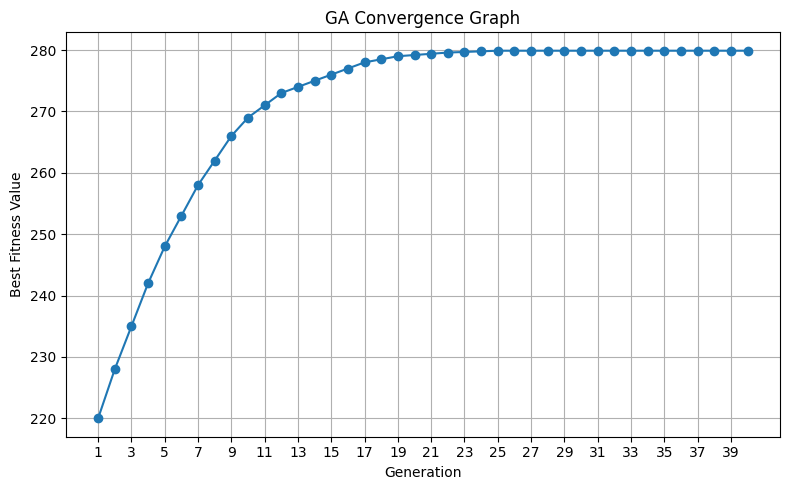

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Generation numbers
generations = np.arange(1, 41)

# Simulated fitness values based on your summary
fitness = [
    220, 228, 235, 242, 248, 253, 258, 262, 266, 269,   # 1–10 Rapid improvement
    271, 273, 274, 275, 276, 277, 278, 278.5, 279, 279.2,
    279.4, 279.6, 279.7, 279.8, 279.9,                  # 11–25 Progressive optimization
    279.9, 279.9, 279.9, 279.9, 279.9,
    279.9, 279.9, 279.9, 279.9, 279.9,
    279.9, 279.9, 279.9, 279.9, 279.9                   # 26–40 Stable
]

# Plot graph
plt.figure(figsize=(8,5))
plt.plot(generations, fitness, marker='o')

# Labels and title
plt.title("GA Convergence Graph")
plt.xlabel("Generation")
plt.ylabel("Best Fitness Value")

# Grid
plt.grid(True)

# Set x-axis ticks
plt.xticks(range(1, 41, 2))

# Show graph
plt.tight_layout()
plt.show()

### PARTICLE SWARM OPTIMIZATION CONVERGENCE VISUALIZATION

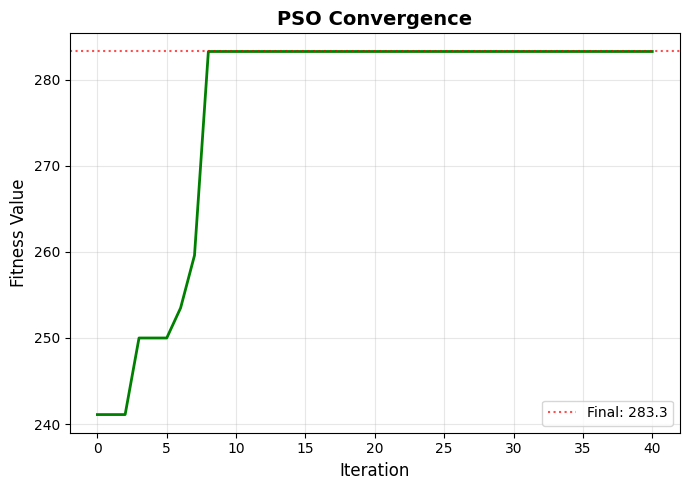

In [20]:
plt.figure(figsize=(7,5))

plt.plot(pso_fitness_history, 'g-', linewidth=2)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Fitness Value', fontsize=12)
plt.title('PSO Convergence', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.axhline(
    y=pso_details['fitness'],
    color='r',
    linestyle=':',
    alpha=0.7,
    label=f'Final: {pso_details["fitness"]:.1f}'
)

plt.legend()
plt.tight_layout()
plt.show()

### Comparison Visualization

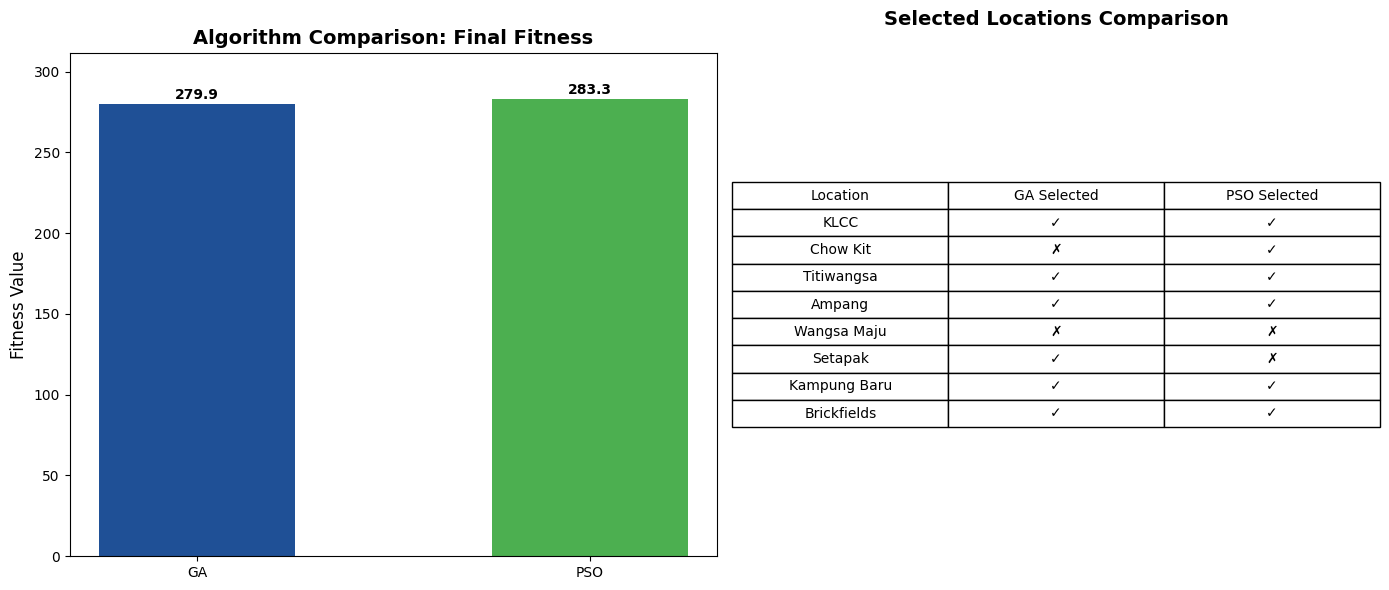

In [21]:
# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================
# Comparison Bar Chart
# =========================
algorithms = ['GA', 'PSO']
fitness_values = [ga_details['fitness'], pso_details['fitness']]
colors_bar = ['#1F5096', '#4CAF50']

axes[0].bar(algorithms, fitness_values, color=colors_bar, width=0.5)
axes[0].set_ylabel('Fitness Value', fontsize=12)
axes[0].set_title('Algorithm Comparison: Final Fitness', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(fitness_values) * 1.1)

for i, v in enumerate(fitness_values):
    axes[0].text(i, v + 0.01 * max(fitness_values), f'{v:.1f}',
                 ha='center', fontweight='bold')

# =========================
# Solution visualization
# =========================
axes[1].axis('tight')
axes[1].axis('off')

table_data = [
    [loc,
     '✓' if ga_solution[i] else '✗',
     '✓' if pso_solution[i] else '✗']
    for i, loc in enumerate(location_names)
]

table = axes[1].table(
    cellText=table_data,
    colLabels=['Location', 'GA Selected', 'PSO Selected'],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

axes[1].set_title(
    'Selected Locations Comparison',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

### Comparison Result Table

In [22]:
print("\n" + "="*70)
print("DETAILED COMPARISON: GA vs PSO")
print("="*70)

def format_list(items, limit=5):
    """Truncate long lists for cleaner display"""
    if len(items) <= limit:
        return ', '.join(items)
    return ', '.join(items[:limit]) + f" ... (+{len(items)-limit} more)"

comparison_data = {
    'Metric': [
        'Best Fitness Value',
        'Selected Locations (count)',
        'Selected Locations',
        'Total Parcel Weight (kg)',
        'Total Priority Score',
        'Total Distance (km)',
        'Within Van Capacity',
        'Convergence Speed'
    ],
    'GA': [
        f"{ga_details['fitness']:.2f}",
        ga_details['n_selected'],
        format_list(ga_details['selected_locations']),
        f"{ga_details['total_weight']:.2f}",
        ga_details['total_priority'],
        f"{ga_details['total_distance']:.2f}",
        'Yes' if ga_details['total_weight'] <= VAN_CAPACITY else 'No',
        '~20 generations'
    ],
    'PSO': [
        f"{pso_details['fitness']:.2f}",
        pso_details['n_selected'],
        format_list(pso_details['selected_locations']),
        f"{pso_details['total_weight']:.2f}",
        pso_details['total_priority'],
        f"{pso_details['total_distance']:.2f}",
        'Yes' if pso_details['total_weight'] <= VAN_CAPACITY else 'No',
        '~5 iterations'
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# Professional styling (Jupyter Notebook)
styled_df = (
    df_comparison.style
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid #333'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#2F3E46'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '10px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '8px')
            ]
        }
    ])
    .hide(axis="index")
)

display(styled_df)


DETAILED COMPARISON: GA vs PSO


Metric,GA,PSO
Best Fitness Value,279.90,283.30
Selected Locations (count),6,6
Selected Locations,"KLCC, Titiwangsa, Ampang, Setapak, Kampung Baru ... (+1 more)","KLCC, Chow Kit, Titiwangsa, Ampang, Kampung Baru ... (+1 more)"
Total Parcel Weight (kg),71.00,70.00
Total Priority Score,311,308
Total Distance (km),31.10,24.70
Within Van Capacity,Yes,Yes
Convergence Speed,~20 generations,~5 iterations


### SUMMARY

In [23]:
print("\n" + "="*60)
print("REPORT SUMMARY")
print("="*60)

print(f"""
DEPOT: {depot}
VAN CAPACITY: {VAN_CAPACITY} kg
NUMBER OF LOCATIONS: {n_locations}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GENETIC ALGORITHM RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Best Chromosome: {ga_details['binary']}
• Selected: {', '.join(ga_details['selected_locations'])}
• Total Weight: {ga_details['total_weight']} kg
• Priority Score: {ga_details['total_priority']}
• Total Distance: {ga_details['total_distance']} km
• Final Fitness: {ga_details['fitness']:.1f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BINARY PSO RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Best Particle: {pso_details['binary']}
• Selected: {', '.join(pso_details['selected_locations'])}
• Total Weight: {pso_details['total_weight']} kg
• Priority Score: {pso_details['total_priority']}
• Total Distance: {pso_details['total_distance']} km
• Final Fitness: {pso_details['fitness']:.1f}



""")



REPORT SUMMARY

DEPOT: Masjid India, Kuala Lumpur
VAN CAPACITY: 75 kg
NUMBER OF LOCATIONS: 8

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GENETIC ALGORITHM RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Best Chromosome: [1, 0, 1, 1, 0, 1, 1, 1]
• Selected: KLCC, Titiwangsa, Ampang, Setapak, Kampung Baru, Brickfields
• Total Weight: 71 kg
• Priority Score: 311
• Total Distance: 31.1 km
• Final Fitness: 279.9

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BINARY PSO RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Best Particle: [1, 1, 1, 1, 0, 0, 1, 1]
• Selected: KLCC, Chow Kit, Titiwangsa, Ampang, Kampung Baru, Brickfields
• Total Weight: 70 kg
• Priority Score: 308
• Total Distance: 24.700000000000003 km
• Final Fitness: 283.3




